# 08 - Visualizations  

This is the presentation side of the project. The goal here was to turn the modeling output into charts that are easy to read and easy to talk through.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED = ROOT / "data" / "processed"
DOC_IMAGES = ROOT / "docs" / "images"
DOC_IMAGES.mkdir(parents=True, exist_ok=True)

In [2]:
daily_df = pd.read_csv(PROCESSED / "focus_age_daily_arrivals.csv", parse_dates=["admission_date"])
stat_df = pd.read_csv(PROCESSED / "statistical_model_predictions.csv", parse_dates=["admission_date"])
lstm_df = pd.read_csv(PROCESSED / "lstm_model_predictions.csv", parse_dates=["admission_date"])

In [3]:
observed_end = stat_df.loc[stat_df["arrivals"].notna(), "admission_date"].max()

In [4]:
def first_arrival_distribution(future_df, prediction_col):
    lambdas = future_df[prediction_col].fillna(0).clip(lower=0).to_numpy(dtype=float)
    no_arrival_prefix = np.exp(-np.cumsum(np.r_[0.0, lambdas[:-1]]))
    first_arrival_prob = no_arrival_prefix * (1 - np.exp(-lambdas))
    return pd.DataFrame(
        {
            "admission_date": future_df["admission_date"].to_numpy(),
            "first_arrival_probability": first_arrival_prob,
        }
    )

In [5]:
plot_df = daily_df[["admission_date", "arrivals"]].copy()
plot_df["rolling_21d"] = plot_df["arrivals"].rolling(21, min_periods=1).mean()

## Rolling Arrivals View

This first chart is the broad seasonality picture. I like starting here because it quickly shows when the arrival pattern starts waking up.


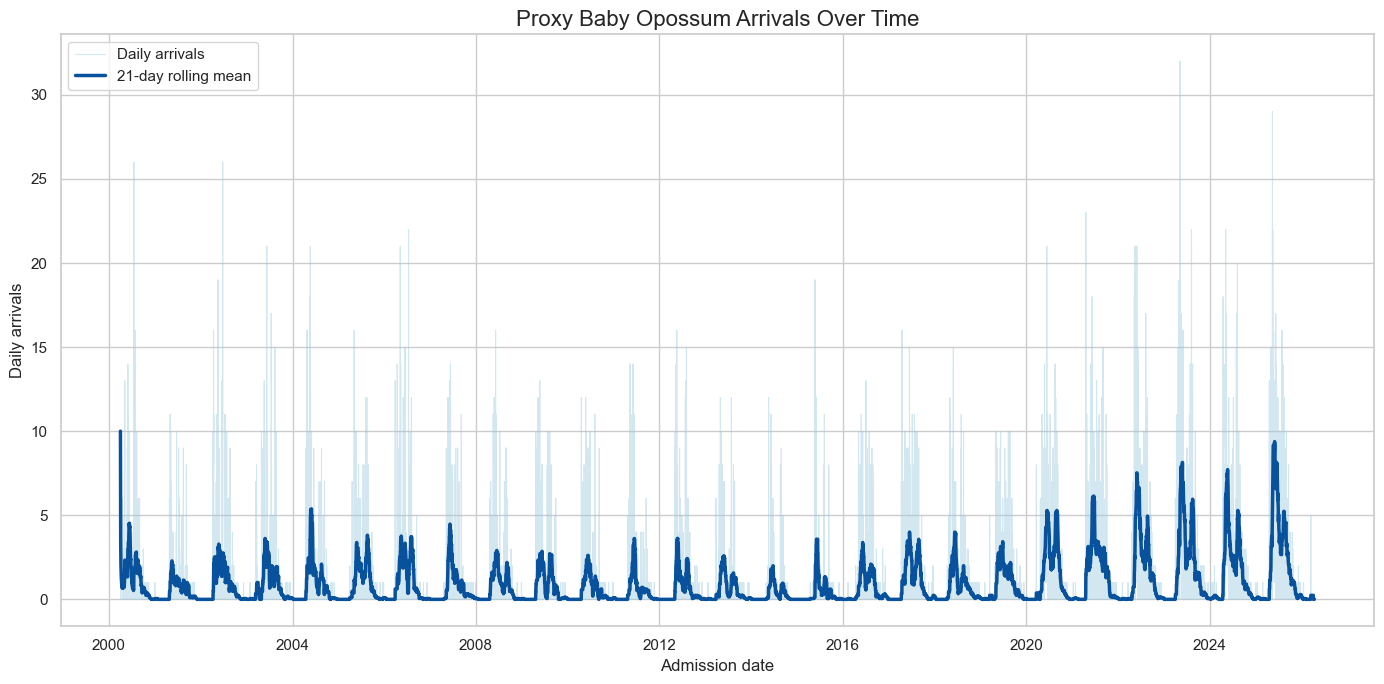

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(plot_df["admission_date"], plot_df["arrivals"], color="#9ecae1", linewidth=0.8, alpha=0.45, label="Daily arrivals")
ax.plot(plot_df["admission_date"], plot_df["rolling_21d"], color="#08519c", linewidth=2.5, label="21-day rolling mean")
ax.set_title("Proxy Baby Opossum Arrivals Over Time")
ax.set_xlabel("Admission date")
ax.set_ylabel("Daily arrivals")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "time_series_context.png", dpi=200, bbox_inches="tight")
plt.show()

## Raw Seasonal Curve

This one keeps the visual a little closer to the original daily series. It's useful when I want the messiness back instead of only looking at smoothed movement.


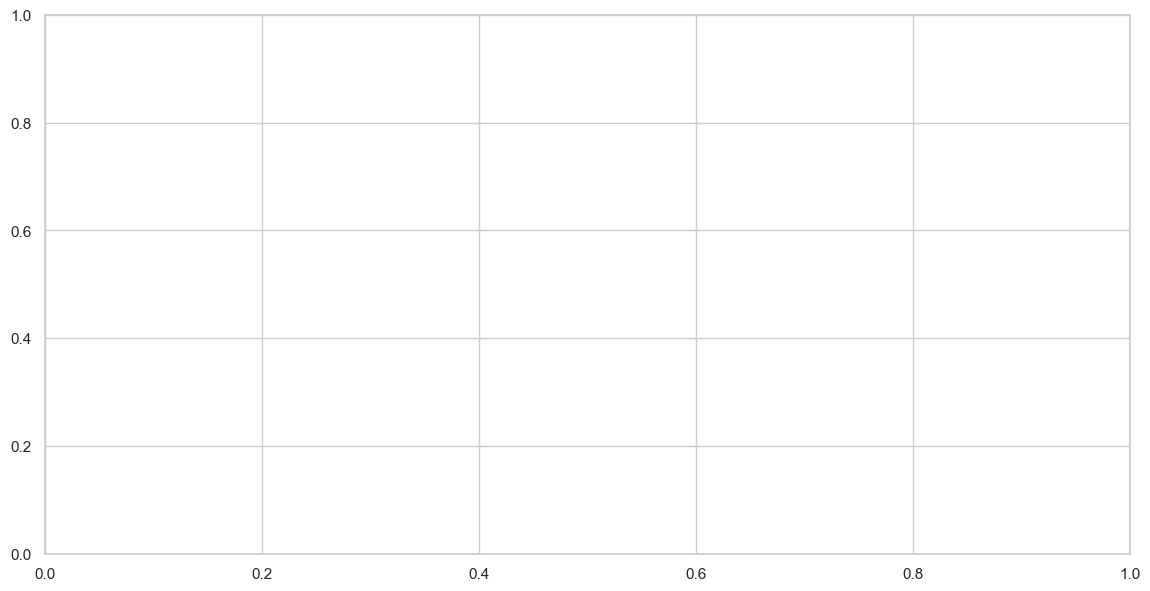

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

observed = stat_df[stat_df["admission_date"] <= observed_end].copy()
future = stat_df[stat_df["admission_date"] > observed_end].copy()

## Model Overlay On Observed And Future Data

This is the main presentation plot for the classical and supervised models. The point here is to compare how each forecast behaves once it moves from observed data into the future window.


In [8]:
ax.plot(observed["admission_date"], observed["arrivals"], color="#252525", linewidth=2.2, label="Observed arrivals")
ax.plot(observed["admission_date"], observed["sarimax_pred"], color="#d95f0e", linewidth=2.2, label="SARIMA fit")
ax.plot(future["admission_date"], future["sarimax_pred"], color="#d95f0e", linewidth=2.2, linestyle="--", label="SARIMA forecast")
ax.axvline(observed_end, color="#636363", linestyle=":", linewidth=2)
ax.annotate("Forecast begins", xy=(observed_end, ax.get_ylim()[1] * 0.85), xytext=(10, 0), textcoords="offset points", color="#525252")
ax.set_title("SARIMA Forecast for 2026 Proxy Baby Arrivals")
ax.set_xlabel("Admission date")
ax.set_ylabel("Daily arrivals")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "sarima_showcase.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
future_lstm = lstm_df[lstm_df["arrivals"].isna()].copy()

model_styles = {
    "LSTM_pred": {"label": "LSTM", "color": "#2b8cbe", "linewidth": 3.0, "alpha": 1.0},
    "Bidirectional LSTM_pred": {"label": "Bidirectional LSTM", "color": "#7bccc4", "linewidth": 2.0, "alpha": 0.9},
    "Stacked LSTM_pred": {"label": "Stacked LSTM", "color": "#8856a7", "linewidth": 2.0, "alpha": 0.9},
}

## LSTM First Arrival Timing

This chart zooms in on the LSTM family and treats the forecast as a timing problem. It's a nice way to talk about uncertainty without pretending we know the exact first-arrival day.


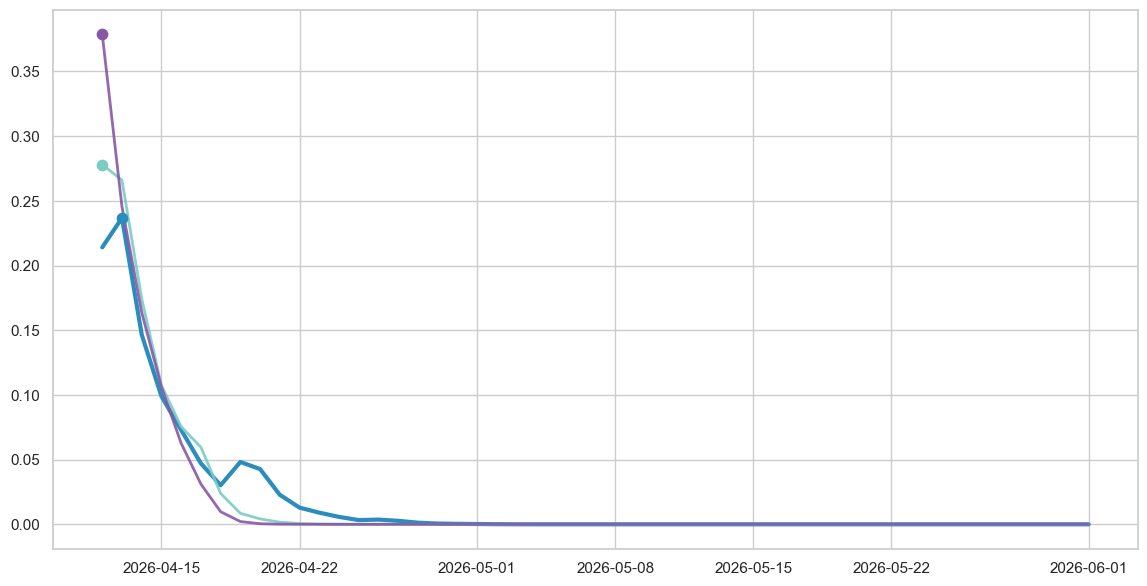

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

for col, style in model_styles.items():
    curve = first_arrival_distribution(future_lstm, col)
    ax.plot(
        curve["admission_date"],
        curve["first_arrival_probability"],
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"],
        label=style["label"],
    )
    peak = curve.loc[curve["first_arrival_probability"].idxmax()]
    ax.scatter(peak["admission_date"], peak["first_arrival_probability"], color=style["color"], s=55, zorder=3)


In [11]:
ax.set_title("LSTM Family First-Arrival Probability After the Observed Window")
ax.set_xlabel("Admission date")
ax.set_ylabel("First-arrival probability")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(DOC_IMAGES / "lstm_showcase.png", dpi=200, bbox_inches="tight")
plt.show()